In [1]:

%matplotlib widget
import numpy as np
from numpy.fft import fftshift
import matplotlib.pyplot as plt
from scipy.datasets import ascent

import pycuda
import pycuda.autoinit
import pycuda.gpuarray as cua
from pyvkfft.base import primes, primes_str
from pyvkfft.fft import rfftn, irfftn, fftn, ifftn
from pyvkfft.cuda import VkFFTApp

# import jax.numpy as jnp

/home/weik/anaconda3/envs/jax/lib/python3.12/site-packages/pytools/persistent_dict.py:52: RecommendedHashNotFoundWarning: Unable to import recommended hash 'siphash24.siphash13', falling back to 'hashlib.sha256'. Run 'python3 -m pip install siphash24' to install the recommended hash.
  warn("Unable to import recommended hash 'siphash24.siphash13', "


# 2D convolution

True

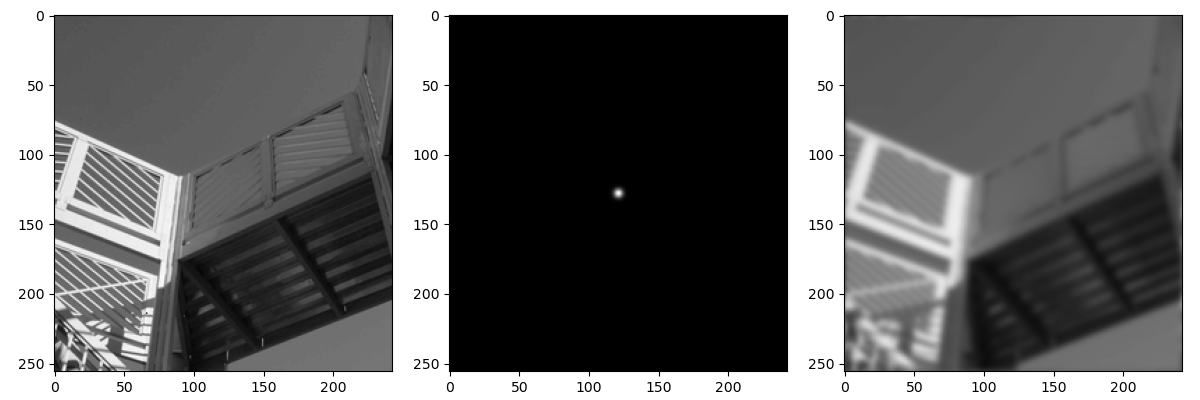

In [2]:
d = ascent()[:256,:243]
r2c_odd = d.shape[-1] % 2
r2c_inplace_pad = 1 if r2c_odd else 2
ny, nx = d.shape
y, x = np.meshgrid(np.arange(-ny//2,ny//2), np.arange(-nx//2,nx//2), indexing='ij')
g = np.fft.fftshift(np.exp(-(x**2+y**2)/10))
g /= g.sum()

# Numpy convolution
d, g = d.astype(np.float32), g.astype(np.float32)
gd_np = np.fft.irfftn(np.fft.rfftn(d) * np.fft.rfftn(g), d.shape)


# move data to GPU
d_gpu = cua.to_gpu(d.astype(np.float32))
g_gpu = cua.to_gpu(g.astype(np.float32))

# Classic convolution
gd_gpu = irfftn(rfftn(d_gpu) * rfftn(g_gpu), r2c_odd=r2c_odd)
gd0 = gd_gpu.get()  # Reference result

plt.figure(figsize=(12,4))
plt.subplot(131)
plt.imshow(d, cmap='gray')
plt.subplot(132)
plt.imshow(np.fft.fftshift(g), cmap='gray')
plt.subplot(133)
plt.imshow(gd_gpu.get(), cmap='gray', vmin=0,vmax=255)
plt.tight_layout()

np.allclose(gd0, gd_np)

VkFFTApp[CUDA]:  (256,243+1)     R2C/s/i/⨂ [rr] [11] buf=    0       0  


True

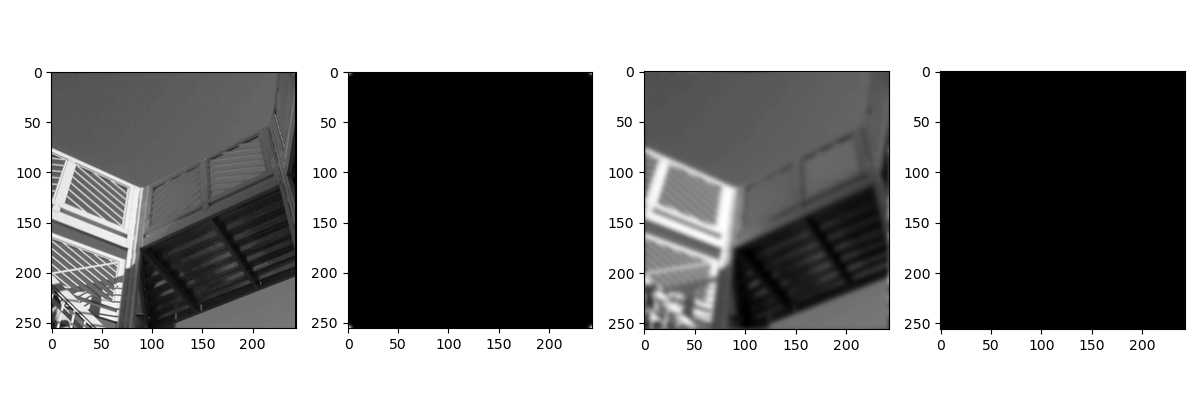

In [8]:
# Inplace R2C with on-the-fly VkFFT convolution
d1 = np.pad(d,((0,0),(0, r2c_inplace_pad)))
g1 = np.pad(g,((0,0),(0, r2c_inplace_pad)))

d_gpu = cua.to_gpu(d1.astype(np.float32))
g_gpu = cua.to_gpu(g1.astype(np.float32))

k_gpu = rfftn(g_gpu, g_gpu, r2c_odd=True)

app = VkFFTApp(d1.shape, dtype=np.float32, ndim=2, inplace=True, r2c=True, convolve=True, convolve_conj=0, r2c_odd=r2c_odd)
app.fft(d_gpu, convolve_kernel=k_gpu)
print(app, app.get_tmp_buffer_str())

plt.figure(figsize=(12,4))
plt.subplot(141)
plt.imshow(d1, cmap='gray')
plt.subplot(142)
plt.imshow(g1, cmap='gray')
plt.subplot(143)
plt.imshow(d_gpu.get()[:,:-r2c_inplace_pad], cmap='gray')
plt.subplot(144)
plt.imshow(d_gpu.get()[:,:-r2c_inplace_pad]-gd0, cmap='gray')
plt.tight_layout()

np.allclose(d_gpu.get()[:,:-r2c_inplace_pad], gd0)

In [9]:
primes_str(243)

'3⁵'

In [13]:
# Out-of-place R2C with on-the-fly VkFFT convolution
d_gpu = cua.to_gpu(d.astype(np.float32))
g_gpu = cua.to_gpu(g.astype(np.float32))
ny, nx = d.shape
gd_gpu = cua.empty((ny, nx//2+1), dtype=np.complex64)

k_gpu = rfftn(g_gpu)

app = VkFFTApp(d.shape, dtype=np.float32, ndim=2, inplace=False, r2c=True, convolve=True, convolve_conj=0)
app.fft(d_gpu, gd_gpu, convolve_kernel=k_gpu)
print(app, app.get_tmp_buffer_str())

plt.figure(figsize=(12,4))
plt.subplot(141)
plt.imshow(d1, cmap='gray')
plt.subplot(142)
plt.imshow(g1, cmap='gray')
plt.subplot(143)
plt.imshow(d_gpu.get(), cmap='gray')
plt.subplot(144)
plt.imshow(d_gpu.get()-gd0, cmap='gray')
plt.tight_layout()

np.allclose(d_gpu.get(), gd0)

RuntimeError: Convolution is not supported for out-of-place R2C transforms

VkFFTApp[CUDA]:  (256,243)       C2C/s/i/⨂ [rr] [11] buf=    0  
    0  


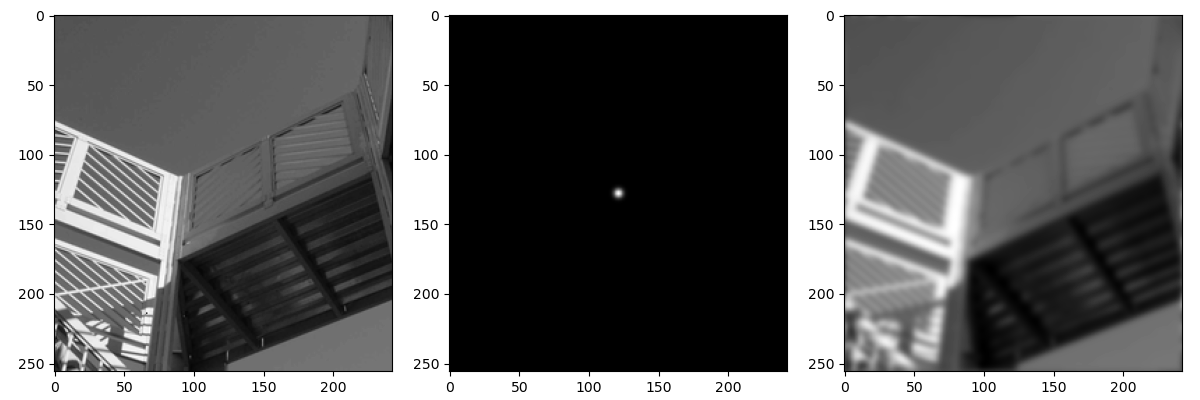

In [3]:
# Inplace C2C VkFFT convolve
d_gpu = cua.to_gpu( d.astype(np.complex64) )
g_gpu = cua.to_gpu( g.astype(np.complex64) )

k_gpu = fftn(g_gpu)

app = VkFFTApp(d.shape, dtype=np.complex64, ndim=2, inplace=True, convolve=True, convolve_conj=0)
gd_gpu = app.fft(src=d_gpu, convolve_kernel=k_gpu)
print(app)
print(app.get_tmp_buffer_str())

plt.figure(figsize=(12,4))
plt.subplot(131)
plt.imshow(d, cmap='gray')
plt.subplot(132)
plt.imshow(np.fft.fftshift(g), cmap='gray')
plt.subplot(133)
plt.imshow(abs(gd_gpu.get()), cmap='gray')
plt.tight_layout()


VkFFTApp[CUDA]:  (256,243)       C2C/s/o/⨂ [rr] [11] buf=    0  
    0  


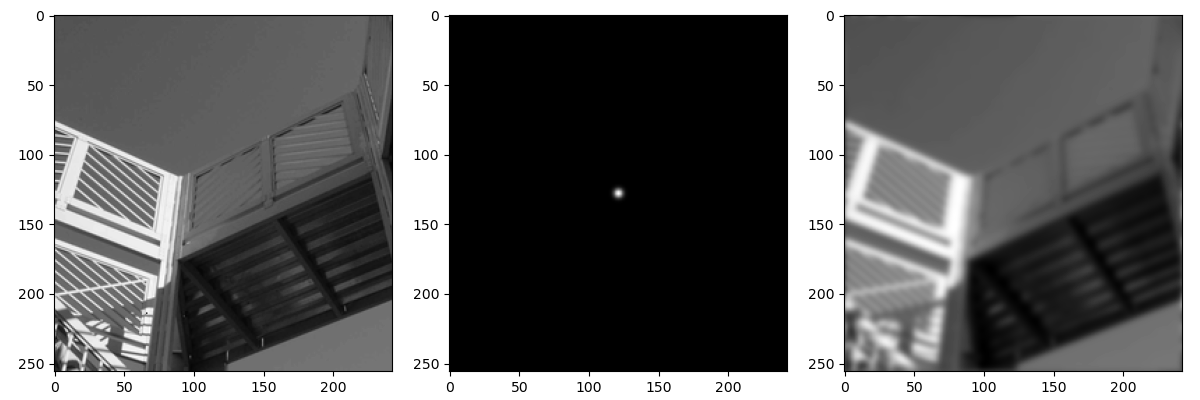

In [ ]:
# Out-of-place C2C VkFFT convolve
d_gpu = cua.to_gpu( d.astype(np.complex64) )
g_gpu = cua.to_gpu( g.astype(np.complex64) )
gd_gpu = cua.empty_like(d_gpu)

k_gpu = fftn(g_gpu)

app = VkFFTApp(d.shape, dtype=np.complex64, ndim=2, inplace=False, convolve=True, convolve_conj=0, convolve_norm=0)
gd_gpu = app.fft(src=d_gpu, dest=gd_gpu, convolve_kernel=k_gpu)
print(app)
print(app.get_tmp_buffer_str())

plt.figure(figsize=(12,4))
plt.subplot(131)
plt.imshow(d, cmap='gray')
plt.subplot(132)
plt.imshow(np.fft.fftshift(g), cmap='gray')
plt.subplot(133)
plt.imshow(abs(gd_gpu.get()), cmap='gray')
plt.tight_layout()


# 2D Convolution, batched

True

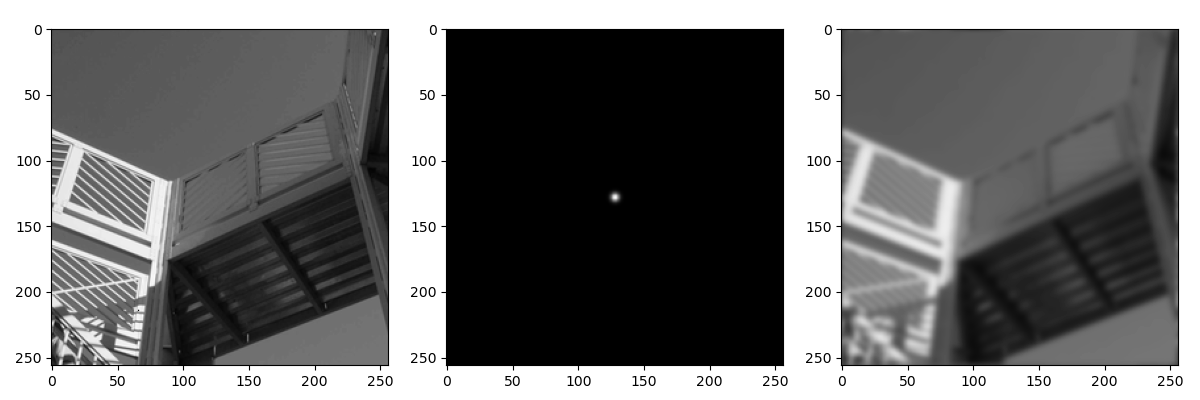

In [18]:
# Standard convolution
nbatch = 4
nbatchk = 4  # batch dimension of kernel
d = ascent()[:256,:256]
ny, nx = d.shape
x, y = np.meshgrid(np.arange(-nx//2,nx//2), np.arange(-ny//2,ny//2), indexing='xy')
g = np.fft.fftshift(np.exp(-(x**2 + y**2) / 10))
g /= g.sum()

# batch
d, g = d.astype(np.float32), g.astype(np.float32)
d = np.tile(d, [nbatch] + [1] * d.ndim)
g = np.tile(g, [nbatchk] + [1] * g.ndim)

if nbatch == nbatchk:
    g_np = g
else:
    g_np = np.tile(g, [nbatch // nbatchk] + [1] * g.ndim)


# Numpy convolution
gd_np = np.fft.irfftn(np.fft.rfftn(d, axes=(-1,-2)) * np.fft.rfftn(g, axes=(-1,-2)), axes=(-1,-2))


# move data to GPU
d_gpu = cua.to_gpu( d.astype(np.float32) )
g_gpu = cua.to_gpu( g.astype(np.float32) )

# Classic convolution
gd_gpu = irfftn(rfftn(d_gpu,ndim=2) * rfftn(g_gpu, ndim=2), ndim=2)
gd0 = gd_gpu.get()  # Reference result

plt.figure(figsize=(12,4))
plt.subplot(131)
plt.imshow(d[0], cmap='gray')
plt.subplot(132)
plt.imshow(np.fft.fftshift(g)[0], cmap='gray')
plt.subplot(133)
plt.imshow(gd_gpu.get()[0], cmap='gray', vmin=0,vmax=255)
plt.tight_layout()

np.allclose(gd_np, gd_gpu.get())

In [19]:
# On-the-fly 2D convolution, R2C, out-of-place, batched
# Standard convolution
nbatch = 4
nbatchk = 2  # batch dimension of kernel
d = ascent()[:256,:256]
ny, nx = d.shape
y, x = np.meshgrid(np.arange(-ny//2,ny//2), np.arange(-nx//2,nx//2), indexing='ij')
g = np.fft.fftshift(np.exp(-(x**2+y**2)/10))
g /= g.sum()

# batch
d, g = d.astype(np.float32), g.astype(np.float32)
print(d.shape, g.shape, nbatch, nbatchk)
d = np.tile(d, [nbatch] + [1] * d.ndim)
g = np.tile(g, [nbatchk] + [1] * g.ndim)

# move data to GPU
d_gpu = cua.to_gpu( d.astype(np.float32) )
g_gpu = cua.to_gpu( g.astype(np.float32) )
gd_gpu = cua.empty_like(d_gpu)

# On-the-fly convolution
k_gpu = rfftn(g_gpu)
app = VkFFTApp(d_gpu.shape, dtype=np.float32, ndim=2, inplace=False,r2c=True,convolve=True, convolve_conj=0, convolve_shape=k_gpu.shape)
print(app, app._convolve, app._convolve_shape, app._coordinateFeatures, app._singleKernelMultipleBatches)
gd_gpu = app.fft(d_gpu, gd_gpu, convolve_kernel=k_gpu)
gd0 = gd_gpu.get()  # Reference result

plt.figure(figsize=(12,4))
plt.subplot(131)
plt.imshow(d[0], cmap='gray')
plt.subplot(132)
plt.imshow(np.fft.fftshift(g)[0], cmap='gray')
plt.subplot(133)
plt.imshow(gd_gpu.get()[0], cmap='gray', vmin=0,vmax=255)
plt.tight_layout()

np.allclose(gd_np, gd_gpu.get())

(256, 256) (256, 256) 4 2


RuntimeError: Convolution is not supported for out-of-place R2C transforms

(4, 256, 256) (1, 256, 256) 4 1
VkFFTApp[CUDA]:  (4,256,256)     C2C/s/o/⨂ [-rr] [011] buf=    0   
 True 
 (1, 256, 256) 
 0 
 1


True

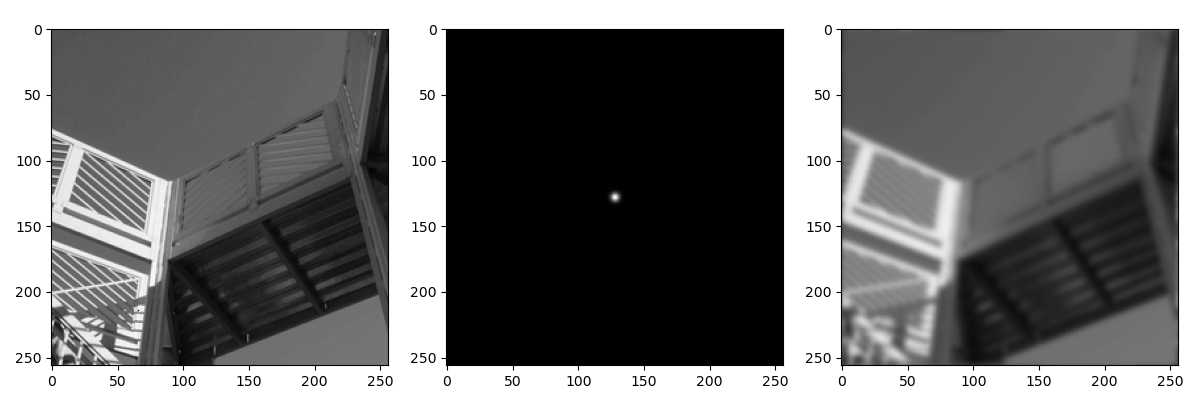

In [ ]:
# On-the-fly 2D convolution, C2C, out-of-place, batched
# Standard convolution
nbatch = 4
nbatchk = 1  # batch dimension of kernel
d = ascent()[:256,:256]
ny, nx = d.shape
y, x = np.meshgrid(np.arange(-ny//2,ny//2), np.arange(-nx//2,nx//2), indexing='ij')
g = np.fft.fftshift(np.exp(-(x**2+y**2)/10))
g /= g.sum()

# batch
d, g = d.astype(np.complex64), g.astype(np.complex64)
d = np.tile(d, [nbatch] + [1] * d.ndim)
g = np.tile(g, [nbatchk] + [1] * g.ndim)
print(d.shape, g.shape, nbatch, nbatchk)

# move data to GPU
d_gpu = cua.to_gpu( d.astype(np.complex64) )
g_gpu = cua.to_gpu( g.astype(np.complex64) )
gd_gpu = cua.empty_like(d_gpu)

# On-the-fly convolution
k_gpu = fftn(g_gpu)
app = VkFFTApp(d_gpu.shape, dtype=np.complex64, ndim=2, inplace=False, convolve=True, convolve_conj=0, convolve_shape=k_gpu.shape)
print(app, '\n', app._convolve, '\n', app._convolve_shape, '\n', app._coordinateFeatures, '\n', app._singleKernelMultipleBatches)
gd_gpu = app.fft(d_gpu, gd_gpu, convolve_kernel=k_gpu)
gd0 = gd_gpu.get()  # Reference result

plt.figure(figsize=(12,4))
plt.subplot(131)
plt.imshow(d[0].real, cmap='gray')
plt.subplot(132)
plt.imshow(np.fft.fftshift(g)[0].real, cmap='gray')
plt.subplot(133)
plt.imshow(gd_gpu.get()[0].real, cmap='gray', vmin=0, vmax=255)
plt.tight_layout()

np.allclose(gd_np, gd_gpu.get())

# 1D convolution

True

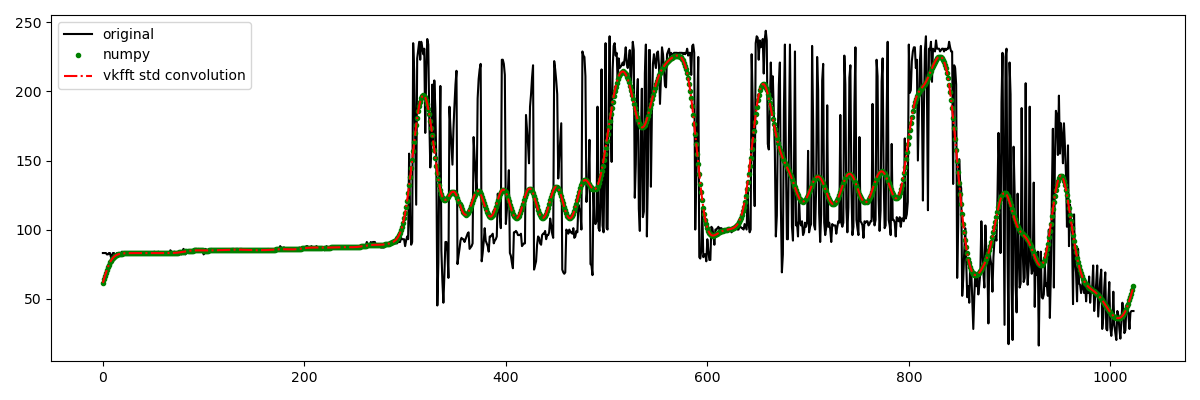

In [22]:
d = ascent()[:256,:4].flatten()
nx = len(d)
x = np.arange(-nx//2,-nx//2+nx)
g = np.fft.fftshift(np.exp(-(x**2)/100))
g /= g.sum()

# Numpy convolution
d, g = d.astype(np.float32), g.astype(np.float32)
gd_np = np.fft.irfftn(np.fft.rfftn(d) * np.fft.rfftn(g))


# move data to GPU
d_gpu = cua.to_gpu( d.astype(np.float32) )
g_gpu = cua.to_gpu( g.astype(np.float32) )

# Classic convolution
gd_gpu = irfftn(rfftn(d_gpu) * rfftn(g_gpu))
gd = gd_gpu.get()  # Reference result

plt.figure(figsize=(12,4))
plt.plot(d,'k', label='original')
plt.plot(gd_np,'g.', label='numpy')
plt.plot(gd,'r-.', label='vkfft std convolution')
plt.legend()
plt.tight_layout()

np.allclose(gd, gd_np)

VkFFTApp[CUDA]:  (1024+2)        R2C/s/i/⨂ [r] [1] buf=    0       0  


False

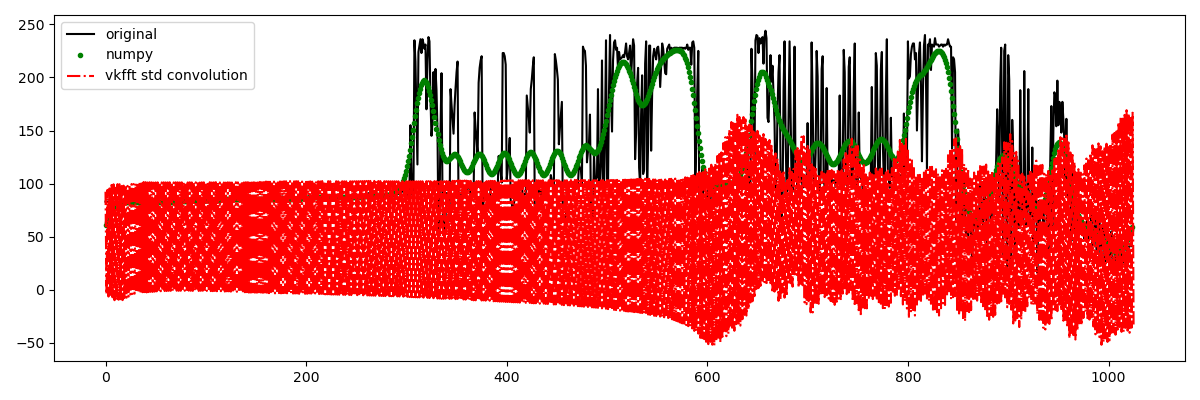

In [ ]:
# Inplace R2C VkFFT on-the-fly convolution
# move data to GPU
d_gpu = cua.to_gpu( np.pad(d,(0,2)) )
g_gpu = cua.to_gpu( np.pad(g,(0,2)) )

# VkFFT convolution
k_gpu = rfftn(g_gpu, g_gpu)
app = VkFFTApp(d_gpu.shape, dtype=np.float32, ndim=1, inplace=True, r2c=True, convolve=True, convolve_conj=0)
gd = app.fft(d_gpu, convolve_kernel=k_gpu).get()
print(app, app.get_tmp_buffer_str())

plt.figure(figsize=(12,4))
plt.plot(d,'k', label='original')
plt.plot(gd_np,'g.', label='numpy')
plt.plot(gd,'r-.', label='vkfft std convolution')
plt.legend()
plt.tight_layout()

np.allclose(gd[:-2], gd_np)

In [ ]:
d.shape, g.shape

VkFFTApp[CUDA]:  (1024)          C2C/s/i/⨂ [r] [1] buf=    0       0  


True

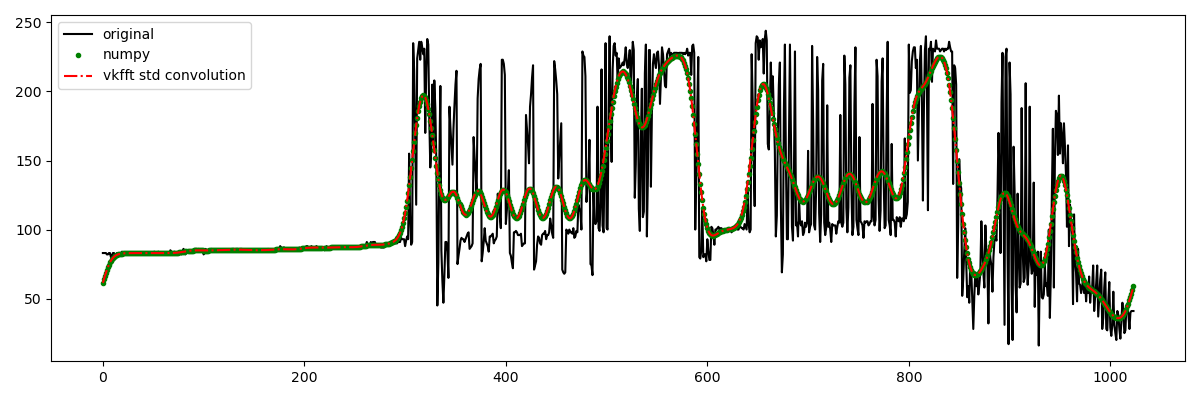

In [24]:
# Inplace C2C VkFFT on-the-fly convolution
# move data to GPU
d_gpu = cua.to_gpu( d.astype(np.complex64) )
g_gpu = cua.to_gpu( g.astype(np.complex64) )

# VkFFT convolution
k_gpu = fftn(g_gpu, g_gpu)
app = VkFFTApp(d_gpu.shape, dtype=np.complex64, ndim=1, inplace=True,convolve=True, convolve_conj=0)
gd = app.fft(d_gpu, convolve_kernel=k_gpu).get().real
print(app, app.get_tmp_buffer_str())

plt.figure(figsize=(12,4))
plt.plot(d,'k', label='original')
plt.plot(gd_np,'g.', label='numpy')
plt.plot(gd,'r-.', label='vkfft std convolution')
plt.legend()
plt.tight_layout()

np.allclose(gd, gd_np)

VkFFTApp[CUDA]:  (1024)          C2C/s/o/⨂ [r] [1] buf=    0       0  


True

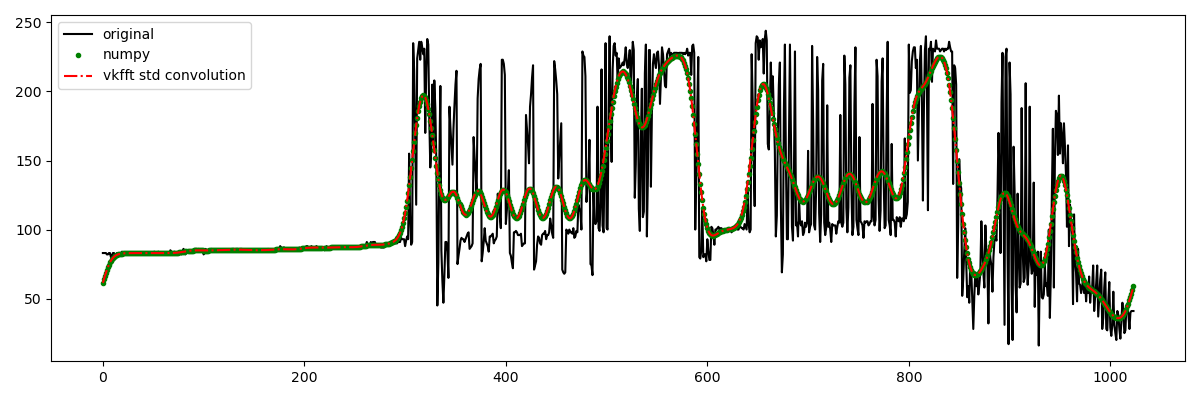

In [25]:
# Out-of-place C2C VkFFT on-the-fly convolution
# move data to GPU
d_gpu = cua.to_gpu( d.astype(np.complex64) )
g_gpu = cua.to_gpu( g.astype(np.complex64) )
gd_gpu = cua.empty_like(d_gpu)

# VkFFT convolution
k_gpu = fftn(g_gpu, g_gpu)
app = VkFFTApp(d_gpu.shape, dtype=np.complex64, ndim=1, inplace=False,convolve=True, convolve_conj=0)
gd = app.fft(d_gpu, gd_gpu, convolve_kernel=k_gpu).get().real
print(app, app.get_tmp_buffer_str())

plt.figure(figsize=(12,4))
plt.plot(d,'k', label='original')
plt.plot(gd_np,'g.', label='numpy')
plt.plot(gd,'r-.', label='vkfft std convolution')
plt.legend()
plt.tight_layout()

np.allclose(gd, gd_np)

VkFFTApp[CUDA]:  (1024)          C2C/s/o/⨂ [r] [1] buf=    0       0  


False

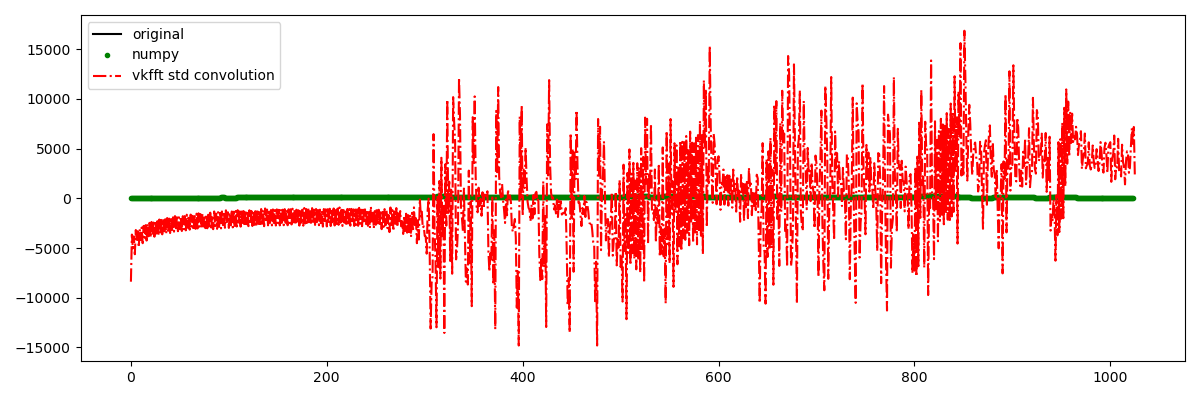

In [27]:
# Out-of-place R2C VkFFT on-the-fly convolution
# move data to GPU
d_gpu = cua.to_gpu( d.astype(np.float32) )
g_gpu = cua.to_gpu( g.astype(np.float32) )
nx = len(d)
gd_gpu = cua.empty( (nx//2+1,), dtype=np.complex64)

# VkFFT convolution
k_gpu = rfftn(g_gpu)
app = VkFFTApp(d_gpu.shape, dtype=np.float32, ndim=1, inplace=False, convolve=True, convolve_conj=0)
gd = app.fft(d_gpu, gd_gpu,convolve_kernel=k_gpu).get().view(dtype=np.float32)
print(app, app.get_tmp_buffer_str())

plt.figure(figsize=(12,4))
plt.plot(d,'k', label='original')
plt.plot(gd_np,'g.', label='numpy')
plt.plot(gd,'r-.', label='vkfft std convolution')
plt.legend()
plt.tight_layout()

np.allclose(gd[:-2], gd_np)

# Batch 1D convolution
works 

True

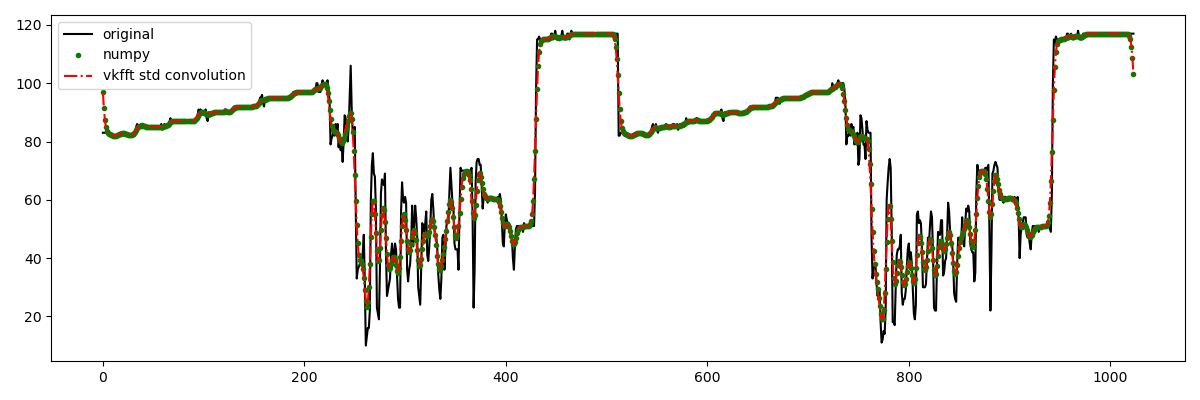

In [28]:
n_batch = 4
n = 1024
d = ascent().flat[:n*n_batch].reshape((n_batch,n))
ny, nx = d.shape
y, x = np.meshgrid(np.arange(-ny//2,ny//2), np.arange(-nx//2,nx//2), indexing='ij')
g = np.fft.fftshift(np.exp(-(x**2)/10))
g /= g[0].sum()

# Numpy convolution
d, g = d.astype(np.float32), g.astype(np.float32)
gd_np = np.fft.irfftn(np.fft.rfftn(d,axes=(-1,)) * np.fft.rfftn(g, axes=(-1,)), axes=(-1,))

# move data to GPU
d_gpu = cua.to_gpu( d.astype(np.float32) )
g_gpu = cua.to_gpu( g.astype(np.float32) )

# Classic convolution
gd_gpu = irfftn(rfftn(d_gpu, ndim=1) * rfftn(g_gpu, ndim=1), ndim=1)
gd = gd_gpu.get()  # Reference result

plt.figure(figsize=(12,4))
plt.plot(d[0],'k', label='original')
plt.plot(gd_np[0],'g.', label='numpy')
plt.plot(gd[0],'r-.', label='vkfft std convolution')
plt.legend()
plt.tight_layout()

np.allclose(gd, gd_np)

VkFFTApp[CUDA]:  (4,1024)        C2C/s/i/⨂ [-r] [01] buf=    0       0  


True

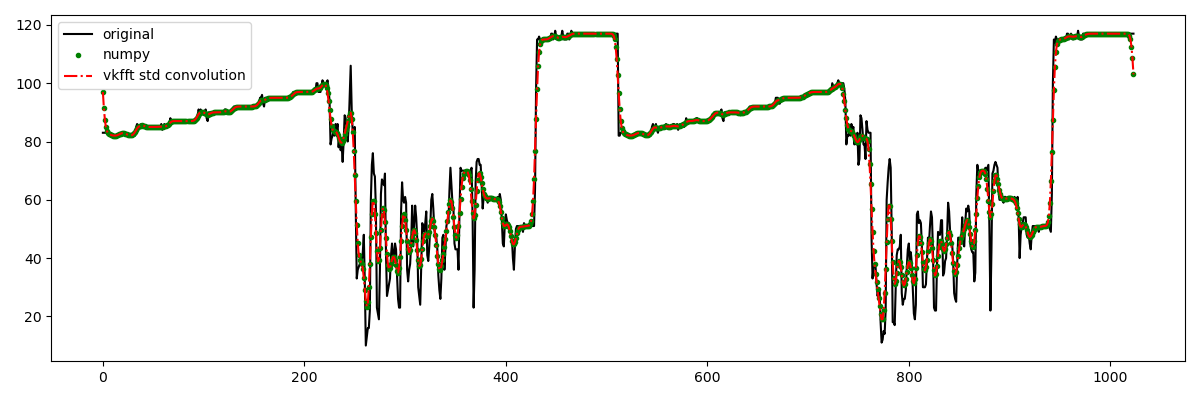

In [30]:
# Inplace C2C VkFFT on-the-fly convolution, batched, kernel has the same size as the array
d_gpu = cua.to_gpu( d.astype(np.complex64) )
g_gpu = cua.to_gpu( g.astype(np.complex64) )

# VkFFT convolution
k_gpu = fftn(g_gpu, g_gpu, ndim=1)
app = VkFFTApp(d_gpu.shape, dtype=np.complex64, ndim=1, inplace=True,convolve=True, convolve_conj=0)
gd = app.fft(d_gpu,convolve_kernel=k_gpu).get()
print(app, app.get_tmp_buffer_str())

plt.figure(figsize=(12,4))
plt.plot(d[0].real,'k', label='original')
plt.plot(gd_np[0].real,'g.', label='numpy')
plt.plot(gd[0].real,'r-.', label='vkfft std convolution')
plt.legend()
plt.tight_layout()

np.allclose(gd, gd_np)

(4, 1024) complex64
(1024,) complex64
VkFFTApp[CUDA]:  (4,1024)        C2C/s/i/⨂ [-r] [01] buf=    0       0  
[1024, 1] [False, True] 1 [1] 4 True 1 0


/tmp/ipykernel_656880/22934253.py:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12,4))


True

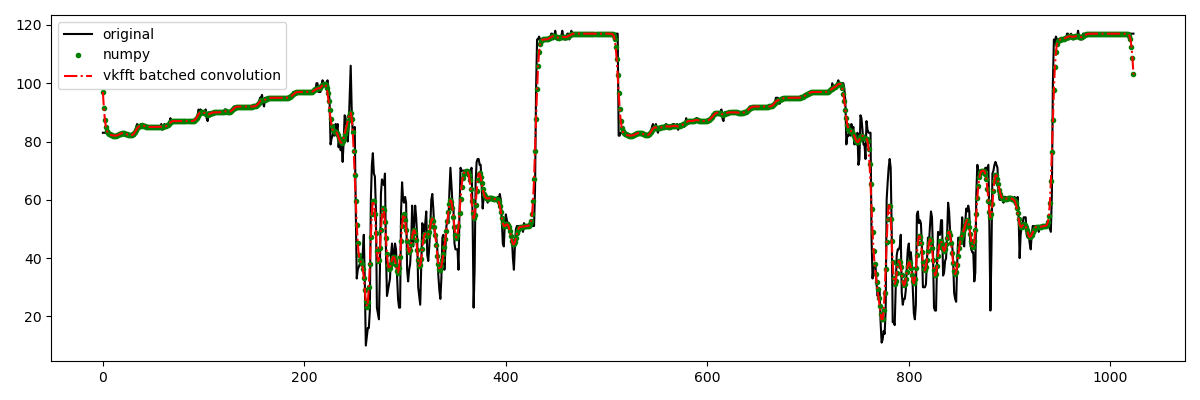

In [34]:
# Inplace C2C VkFFT on-the-fly convolution, batched, 1D kernel
d_gpu = cua.to_gpu( d.astype(np.complex64) )
g_gpu = cua.to_gpu( g.astype(np.complex64)[0] )

print(d_gpu.shape, d_gpu.dtype)
print(g_gpu.shape, g_gpu.dtype)

# VkFFT convolution
k_gpu = fftn(g_gpu, g_gpu, ndim=1)
app = VkFFTApp(d_gpu.shape, dtype=np.complex64, ndim=1, inplace=True, convolve=True, convolve_conj=0, convolve_shape=g_gpu.shape)
gd = app.fft(d_gpu,convolve_kernel=k_gpu).get()
print(app, app.get_tmp_buffer_str())
print(app.shape, app.skip_axis, app.ndim, app.axes0, app.n_batch, app._convolve, app._singleKernelMultipleBatches, app._coordinateFeatures)
plt.figure(figsize=(12,4))
i = 0
plt.plot(d[i].real,'k', label='original')
plt.plot(gd_np[i].real,'g.', label='numpy')
plt.plot(gd[i].real,'r-.', label='vkfft batched convolution')
plt.legend()
plt.tight_layout()

np.allclose(gd, gd_np)

(4, 1024) complex64
(2, 1024) complex64
VkFFTApp[CUDA]:  (4,1024)        C2C/s/i/⨂ [-r] [01] buf=    0       0  
[1024, 1] [False, True] 1 [1] 2 True 1 2


True

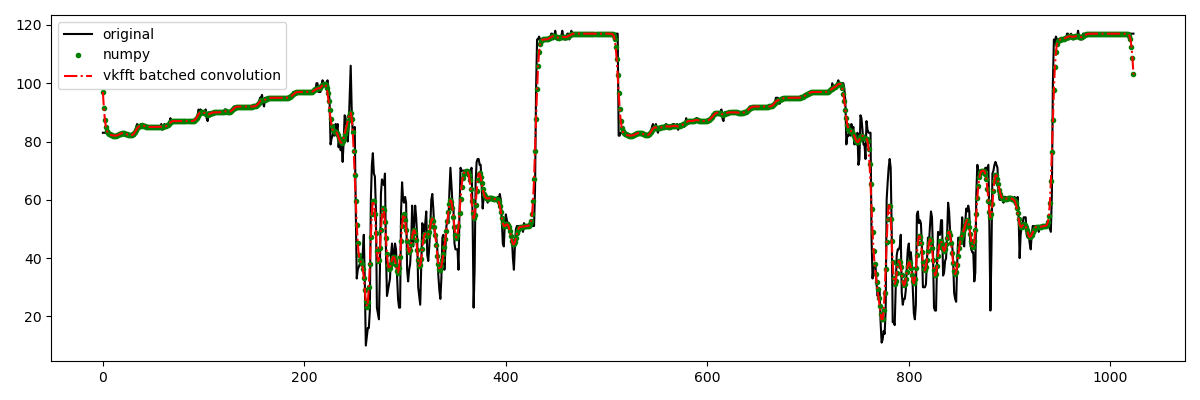

In [37]:
# Inplace C2C VkFFT on-the-fly convolution, batched, array is (4,1024) and kernel (2,1024)
d_gpu = cua.to_gpu( d.astype(np.complex64) )
g_gpu = cua.to_gpu( g.astype(np.complex64)[:2] )

print(d_gpu.shape, d_gpu.dtype)
print(g_gpu.shape, g_gpu.dtype)

# VkFFT convolution
k_gpu = fftn(g_gpu, g_gpu, ndim=1)
app = VkFFTApp(d_gpu.shape, dtype=np.complex64, ndim=1, inplace=True,convolve=True, convolve_conj=0, convolve_shape=g_gpu.shape)
gd = app.fft(d_gpu,convolve_kernel=k_gpu).get()
print(app, app.get_tmp_buffer_str())
print(app.shape, app.skip_axis, app.ndim, app.axes0, app.n_batch, app._convolve, app._singleKernelMultipleBatches, app._coordinateFeatures)
plt.figure(figsize=(12,4))
i = 0
plt.plot(d[i].real,'k', label='original')
plt.plot(gd_np[i].real,'g.', label='numpy')
plt.plot(gd[i].real,'r-.', label='vkfft batched convolution')
plt.legend()
plt.tight_layout()

np.allclose(gd, gd_np)

(4, 1024) complex64
(4, 1024) complex64
VkFFTApp[CUDA]:  (4,1024)        C2C/s/o/⨂ [-r] [01] buf=    0       0  


True

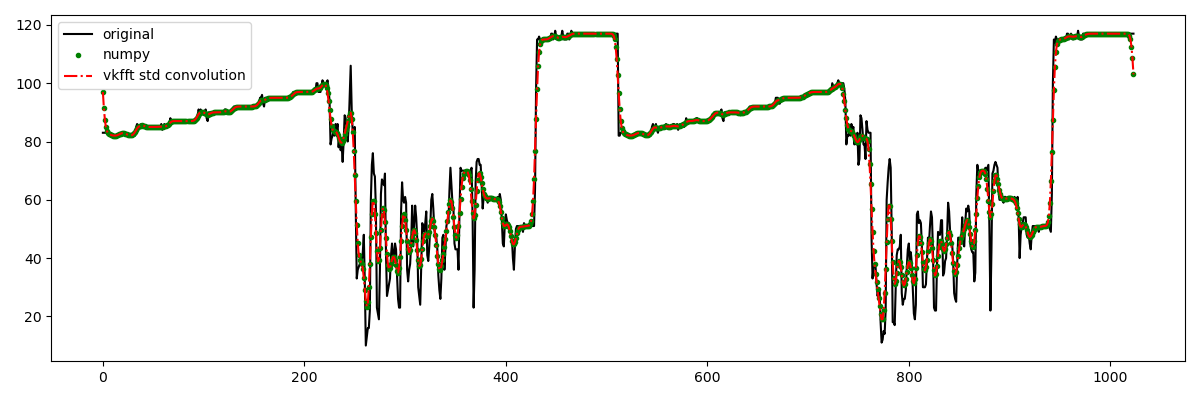

In [38]:
# Out-of-place C2C VkFFT on-the-fly convolution
d_gpu = cua.to_gpu( d.astype(np.complex64) )
g_gpu = cua.to_gpu( g.astype(np.complex64) )
gd_gpu = cua.empty_like(d_gpu)

print(d_gpu.shape, d_gpu.dtype)
print(g_gpu.shape, g_gpu.dtype)

# VkFFT convolution
k_gpu = fftn(g_gpu, g_gpu, ndim=1)
app = VkFFTApp(d_gpu.shape, dtype=np.complex64, ndim=1, inplace=False,convolve=True, convolve_conj=0)
gd = app.fft(d_gpu, gd_gpu,convolve_kernel=k_gpu).get()
print(app, app.get_tmp_buffer_str())

plt.figure(figsize=(12,4))
plt.plot(d[0].real,'k', label='original')
plt.plot(gd_np[0].real,'g.', label='numpy')
plt.plot(gd[0].real,'r-.', label='vkfft std convolution')
plt.legend()
plt.tight_layout()

np.allclose(gd, gd_np)

# 3D convolution
OK

In [ ]:
n = 128
d = np.empty((n,n,n),dtype=np.float32)
# Random shift for each layer to make sure transform is not trivial
for i in range(n):
    d[i] = np.roll(ascent()[:n,:n], np.random.randint(-10,10,2))
nz, ny, nx = d.shape
z, y, x = np.meshgrid(np.arange(-nz//2,nz//2), np.arange(-ny//2,ny//2), np.arange(-nx//2,nx//2), indexing='ij')
g = np.fft.fftshift(np.exp(-(x**2+y**2+z**2)/10))
g /= g.sum()

# Numpy convolution
d, g = d.astype(np.float32), g.astype(np.float32)
gd_np = np.fft.irfftn(np.fft.rfftn(d) * np.fft.rfftn(g))

# move data to GPU
d_gpu = cua.to_gpu(d.astype(np.float32))
g_gpu = cua.to_gpu(g.astype(np.float32))

# Classic convolution
gd_gpu = irfftn(rfftn(d_gpu) * rfftn(g_gpu))
gd = gd_gpu.get()  # Reference result

plt.figure(figsize=(12,4))
plt.subplot(131)
plt.imshow(d[n//2], cmap='gray')
plt.subplot(132)
plt.imshow(np.fft.fftshift(g)[n//2], cmap='gray')
plt.subplot(133)
plt.imshow(gd[n//2], cmap='gray')
plt.tight_layout()

np.allclose(gd, gd_np)

In [ ]:
# Using inplace R2C VkFFT on-the-fly transform

# move data to GPU
d_gpu = cua.to_gpu( np.pad(d,((0,0),(0,0),(0,2))) )
g_gpu = cua.to_gpu( np.pad(g,((0,0),(0,0),(0,2))) )

k_gpu = rfftn(g_gpu, g_gpu)

app = VkFFTApp(d_gpu.shape, dtype=np.float32, ndim=3, inplace=True,r2c=True,convolve=True, convolve_conj=0)
gd = app.fft(d_gpu,convolve_kernel=k_gpu).get()
print(app, app.get_tmp_buffer_str())

plt.figure(figsize=(16,4))
plt.subplot(141)
plt.imshow(d[n//2], cmap='gray')
plt.subplot(142)
plt.imshow(np.fft.fftshift(g)[n//2], cmap='gray')
plt.subplot(143)
plt.imshow(gd[n//2,:,:-2], cmap='gray')
plt.subplot(144)
plt.imshow(gd[n//2,:,:-2]-gd_np[n//2], cmap='gray')
plt.tight_layout()

np.allclose(gd[..., :-2], gd_np)

In [ ]:
# Using inplace C2C VkFFT on-the-fly transform

# move data to GPU
d_gpu = cua.to_gpu( d.astype(np.complex64) )
g_gpu = cua.to_gpu( g.astype(np.complex64) )

k_gpu = fftn(g_gpu, g_gpu)

app = VkFFTApp(d_gpu.shape, dtype=np.complex64, ndim=3, inplace=True, convolve=True, convolve_conj=0)
gd = app.fft(d_gpu,convolve_kernel=k_gpu).get().real
print(app, app.get_tmp_buffer_str())

plt.figure(figsize=(16,4))
plt.subplot(141)
plt.imshow(d[n//2], cmap='gray')
plt.subplot(142)
plt.imshow(np.fft.fftshift(g)[n//2], cmap='gray')
plt.subplot(143)
plt.imshow(gd[n//2], cmap='gray')
plt.subplot(144)
plt.imshow(gd[n//2]-gd_np[n//2], cmap='gray')
plt.tight_layout()

np.allclose(gd, gd_np)

In [ ]:
# Using out-of-place C2C VkFFT on-the-fly transform

# move data to GPU
d_gpu = cua.to_gpu( d.astype(np.complex64) )
g_gpu = cua.to_gpu( g.astype(np.complex64) )
gd_gpu = cua.empty_like(d_gpu)

k_gpu = fftn(g_gpu, g_gpu)

app = VkFFTApp(d_gpu.shape, dtype=np.complex64, ndim=3, inplace=False,convolve=True, convolve_conj=0)
gd = app.fft(d_gpu, gd_gpu,convolve_kernel=k_gpu).get().real
print(app, app.get_tmp_buffer_str())

plt.figure(figsize=(16,4))
plt.subplot(141)
plt.imshow(d[n//2], cmap='gray')
plt.subplot(142)
plt.imshow(np.fft.fftshift(g)[n//2], cmap='gray')
plt.subplot(143)
plt.imshow(gd[n//2], cmap='gray')
plt.subplot(144)
plt.imshow(gd[n//2]-gd_np[n//2], cmap='gray')
plt.tight_layout()

np.allclose(gd, gd_np)

# Batch 2D convolution
works by putting the batch number in VkFFT's ``coordinateFeatures`` instead of numberBatches

True

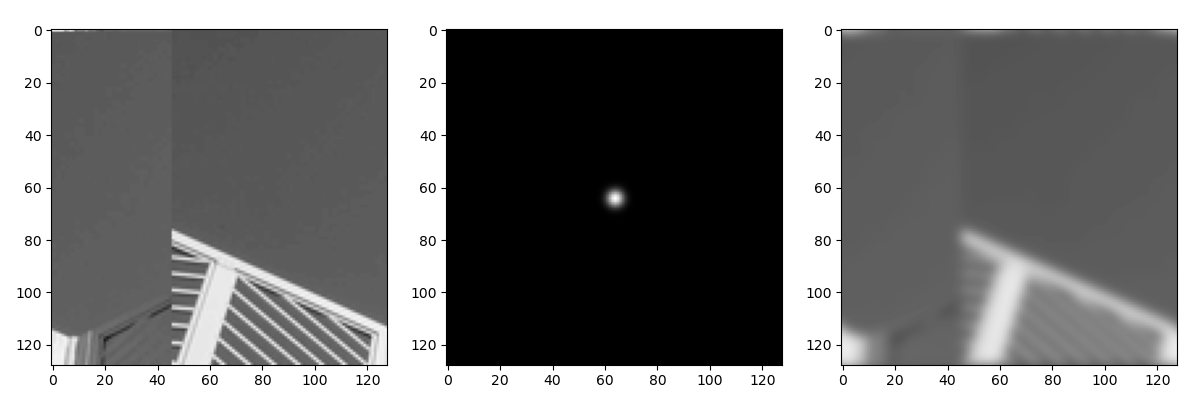

In [39]:
n = 128
d = np.empty((n,n,n),dtype=np.float32)
# Random shift for each layer to make sure transform is not trivial
for i in range(n):
    d[i] = np.roll(ascent()[:n,:n], np.random.randint(-40,40,2))
nz, ny, nx = d.shape
z, y, x = np.meshgrid(np.arange(-nz//2,nz//2), np.arange(-ny//2,ny//2), np.arange(-nx//2,nx//2), indexing='ij')
g = np.fft.fftshift(np.exp(-(x**2+y**2)/10))
g /= g[0].sum()

# Numpy convolution
d, g = d.astype(np.float32), g.astype(np.float32)
gd_np = np.fft.irfftn(np.fft.rfftn(d, axes=(-1,-2)) * np.fft.rfftn(g, axes=(-1,-2)), axes=(-1,-2))

# move data to GPU
d_gpu = cua.to_gpu(d.astype(np.float32))
g_gpu = cua.to_gpu(g.astype(np.float32))

# Classic convolution
gd_gpu = irfftn(rfftn(d_gpu, ndim=2) * rfftn(g_gpu, ndim=2), ndim=2)
gd = gd_gpu.get()  # Reference result

plt.figure(figsize=(12,4))
plt.subplot(131)
plt.imshow(d[n//2], cmap='gray',vmin=0,vmax=255)
plt.subplot(132)
plt.imshow(np.fft.fftshift(g)[n//2], cmap='gray')
plt.subplot(133)
plt.imshow(gd[n//2], cmap='gray',vmin=0,vmax=255)
plt.tight_layout()

np.allclose(gd, gd_np)

VkFFTApp[CUDA]:  (128,128,128+2) R2C/s/i/⨂ [-rr] [011] buf=    0       0  


True

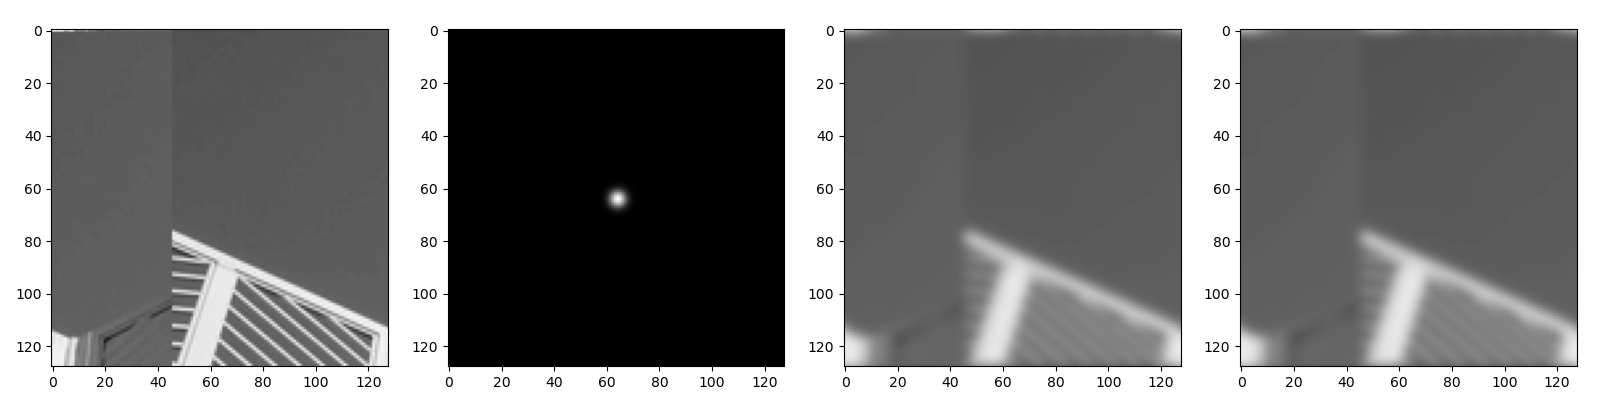

In [ ]:
# Using inplace R2C VkFFT on-the-fly transform

# move data to GPU
d_gpu = cua.to_gpu( np.pad(d,((0,0),(0,0),(0,2))) )
g_gpu = cua.to_gpu( np.pad(g,((0,0),(0,0),(0,2))) )

k_gpu = rfftn(g_gpu, g_gpu, ndim=2)

app = VkFFTApp(d_gpu.shape, dtype=np.float32, ndim=2, inplace=True, r2c=True, convolve=True, convolve_conj=0)
gd = app.fft(d_gpu,convolve_kernel=k_gpu).get()
print(app, app.get_tmp_buffer_str())

plt.figure(figsize=(16,4))
plt.subplot(141)
plt.imshow(d[n//2], cmap='gray',vmin=0,vmax=255)
plt.subplot(142)
plt.imshow(np.fft.fftshift(g)[n//2], cmap='gray')
plt.subplot(143)
plt.imshow(gd[n//2,:,:-2], cmap='gray',vmin=0,vmax=255)
plt.subplot(144)
plt.imshow(gd_np[n//2], cmap='gray',vmin=0,vmax=255)
plt.tight_layout()

np.allclose(gd[..., :-2], gd_np)

(128, 128, 128) complex64
(128, 128, 128) complex64
VkFFTApp[CUDA]:  (128,128,128)   C2C/s/i/⨂ [-rr] [011] buf=    0       0  


True

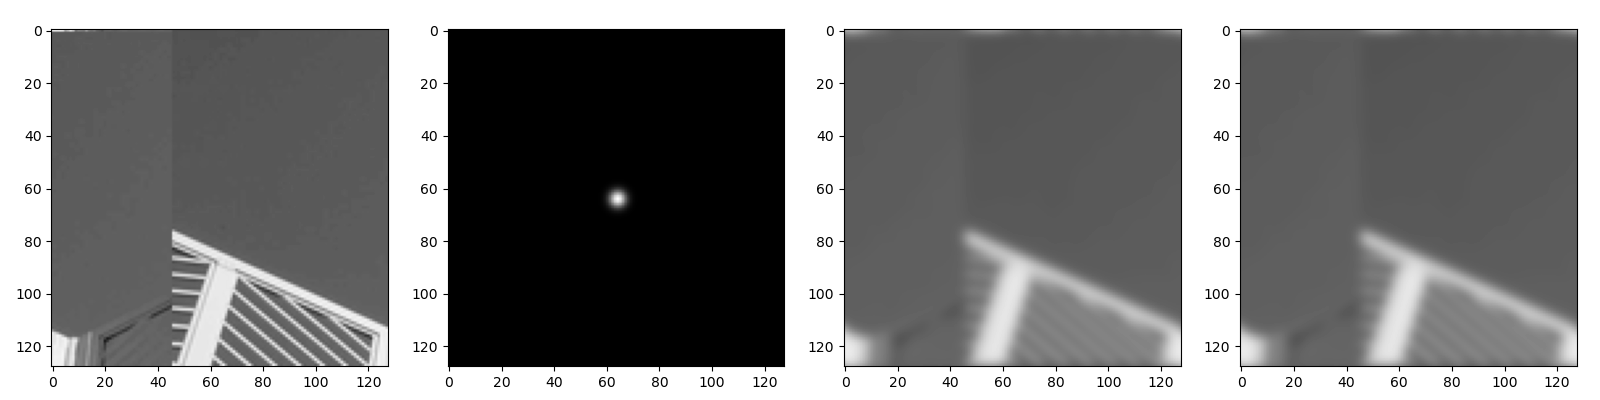

In [41]:
# Using inplace C2C VkFFT on-the-fly transform

# move data to GPU
d_gpu = cua.to_gpu( d.astype(np.complex64) )
g_gpu = cua.to_gpu( g.astype(np.complex64) )

k_gpu = fftn(g_gpu, g_gpu, ndim=2)

print(d_gpu.shape, d_gpu.dtype)
print(k_gpu.shape, k_gpu.dtype)

app = VkFFTApp(d_gpu.shape, dtype=np.complex64, ndim=2, inplace=True, convolve=True, convolve_conj=0)
gd = app.fft(d_gpu, convolve_kernel=k_gpu).get().real
print(app, app.get_tmp_buffer_str())

plt.figure(figsize=(16,4))
plt.subplot(141)
plt.imshow(d[n//2], cmap='gray',vmin=0,vmax=255)
plt.subplot(142)
plt.imshow(np.fft.fftshift(g)[n//2], cmap='gray')
plt.subplot(143)
plt.imshow(gd[n//2], cmap='gray',vmin=0,vmax=255)
plt.subplot(144)
plt.imshow(gd_np[n//2], cmap='gray',vmin=0,vmax=255)
plt.tight_layout()

np.allclose(gd, gd_np)

VkFFTApp[CUDA]:  (128,128,128)   C2C/s/o/⨂ [-rr] [011] buf=    0       0  


True

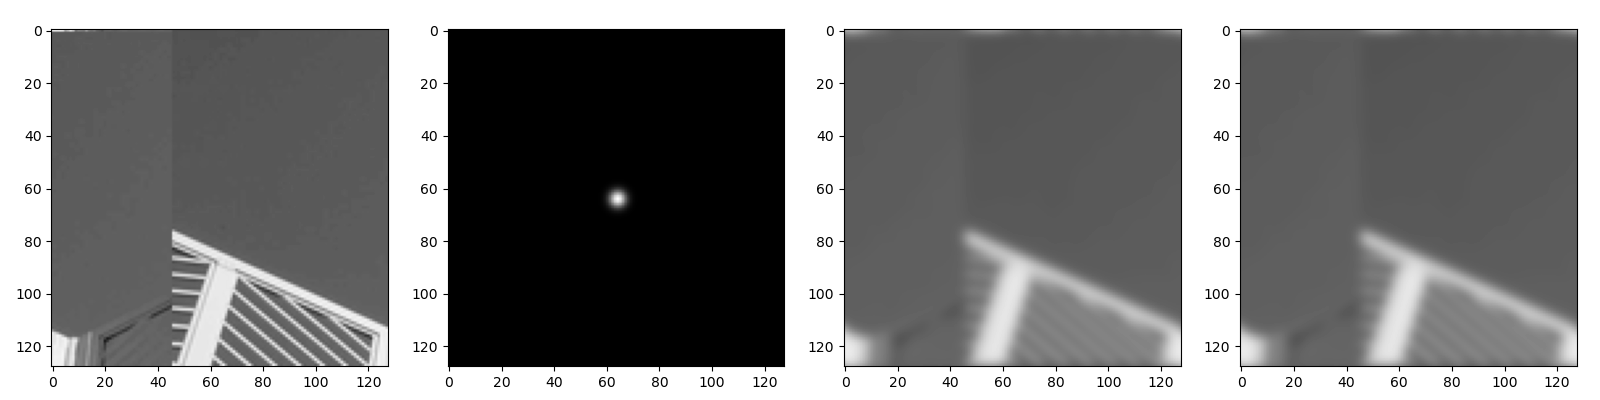

In [42]:
# Using out-of-place C2C VkFFT on-the-fly transform

# move data to GPU
d_gpu = cua.to_gpu(d.astype(np.complex64))
g_gpu = cua.to_gpu(g.astype(np.complex64))
gd_gpu = cua.empty_like(d_gpu)

k_gpu = fftn(g_gpu, g_gpu, ndim=2)

app = VkFFTApp(d_gpu.shape, dtype=np.complex64, ndim=2, inplace=False,convolve=True, convolve_conj=0)
gd = app.fft(d_gpu, gd_gpu,convolve_kernel=k_gpu).get().real
print(app, app.get_tmp_buffer_str())

plt.figure(figsize=(16,4))
plt.subplot(141)
plt.imshow(d[n//2], cmap='gray',vmin=0,vmax=255)
plt.subplot(142)
plt.imshow(np.fft.fftshift(g)[n//2], cmap='gray')
plt.subplot(143)
plt.imshow(gd[n//2], cmap='gray',vmin=0,vmax=255)
plt.subplot(144)
plt.imshow(gd_np[n//2], cmap='gray',vmin=0,vmax=255)
plt.tight_layout()

np.allclose(gd, gd_np)